In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv('air_quality_1000_dataset.csv')

In [4]:
df.head()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,AQI
0,118.62,90.35,42.95,54.47,1.47,76.92,30.93,22.91,117.10
1,285.71,225.92,40.81,64.14,2.03,90.48,11.90,34.01,235.64
2,222.28,351.72,136.41,21.54,1.92,155.27,39.90,82.34,226.30
3,183.61,298.25,41.18,50.74,0.47,67.80,29.52,77.51,189.79
4,55.25,326.49,44.43,46.60,0.46,157.84,11.29,46.30,133.48


In [5]:
df.shape

(1000, 9)

In [6]:
df.dtypes

PM2.5          float64
PM10           float64
NO2            float64
SO2            float64
CO             float64
O3             float64
Temperature    float64
Humidity       float64
AQI            float64
dtype: object

# data cleaning

In [8]:
df.isnull().sum()

PM2.5          0
PM10           0
NO2            0
SO2            0
CO             0
O3             0
Temperature    0
Humidity       0
AQI            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)   # fill missing with mean
df.drop_duplicates(inplace=True)

df.shape

C:\Users\lalub\AppData\Local\Temp\ipykernel_24188\2931260388.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)   # fill missing with mean


(1000, 9)

In [11]:
df.describe()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,AQI
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,152.174370,212.66658,77.848650,40.249350,1.28590,94.738930,24.732180,56.177770,158.18657
std,84.719824,111.03213,42.147776,22.346146,0.68841,49.163073,11.589379,21.368654,51.35436
min,11.340000,21.22000,5.000000,2.050000,0.10000,11.050000,5.060000,20.020000,26.42000
25%,78.435000,111.61000,42.897500,20.870000,0.68750,52.397500,14.610000,37.700000,123.65750
50%,154.075000,217.12000,77.590000,39.770000,1.28500,93.365000,24.385000,56.295000,158.46500
75%,225.850000,308.97750,115.072500,59.530000,1.87250,135.775000,35.255000,73.585000,193.39500
max,299.920000,399.78000,149.680000,79.970000,2.49000,179.890000,44.980000,94.920000,295.78000


In [12]:
# ── 2.4 Outlier Detection — IQR Method ──
print("── Outlier Count per Feature (IQR Method) ──\n")
outlier_info = []
for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info.append({'Feature': col, 'Outliers': n,
                          'Lower Bound': round(lower,2),
                          'Upper Bound': round(upper,2)})
    print(f"  {col:15s}: {n:3d} outliers   range [{lower:.2f}, {upper:.2f}]")

── Outlier Count per Feature (IQR Method) ──

  PM2.5          :   0 outliers   range [-142.69, 446.97]
  PM10           :   0 outliers   range [-184.44, 605.03]
  NO2            :   0 outliers   range [-65.37, 223.34]
  SO2            :   0 outliers   range [-37.12, 117.52]
  CO             :   0 outliers   range [-1.09, 3.65]
  O3             :   0 outliers   range [-72.67, 260.84]
  Temperature    :   0 outliers   range [-16.36, 66.22]
  Humidity       :   0 outliers   range [-16.13, 127.41]
  AQI            :   0 outliers   range [19.05, 298.00]


In [13]:
#  Add AQI Category Label ──
def categorize_aqi(aqi):
    if aqi <= 50:    return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)
print(df['AQI_Category'].value_counts())

AQI_Category
Unhealthy                  353
Unhealthy for Sensitive    289
Very Unhealthy             217
Moderate                   127
Good                        14
Name: count, dtype: int64


# eda

In [14]:
features = ['PM2.5','PM10','NO2','SO2','CO','O3','Temperature','Humidity']
print(f"Feature columns: {features}")
print(f"Target column  : AQI")

Feature columns: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity']
Target column  : AQI


In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
PALETTE = ['#00d4ff','#ff6b6b','#7fff7f','#ffb347',
           '#c39bd3','#76d7c4','#f1948a','#85c1e9']

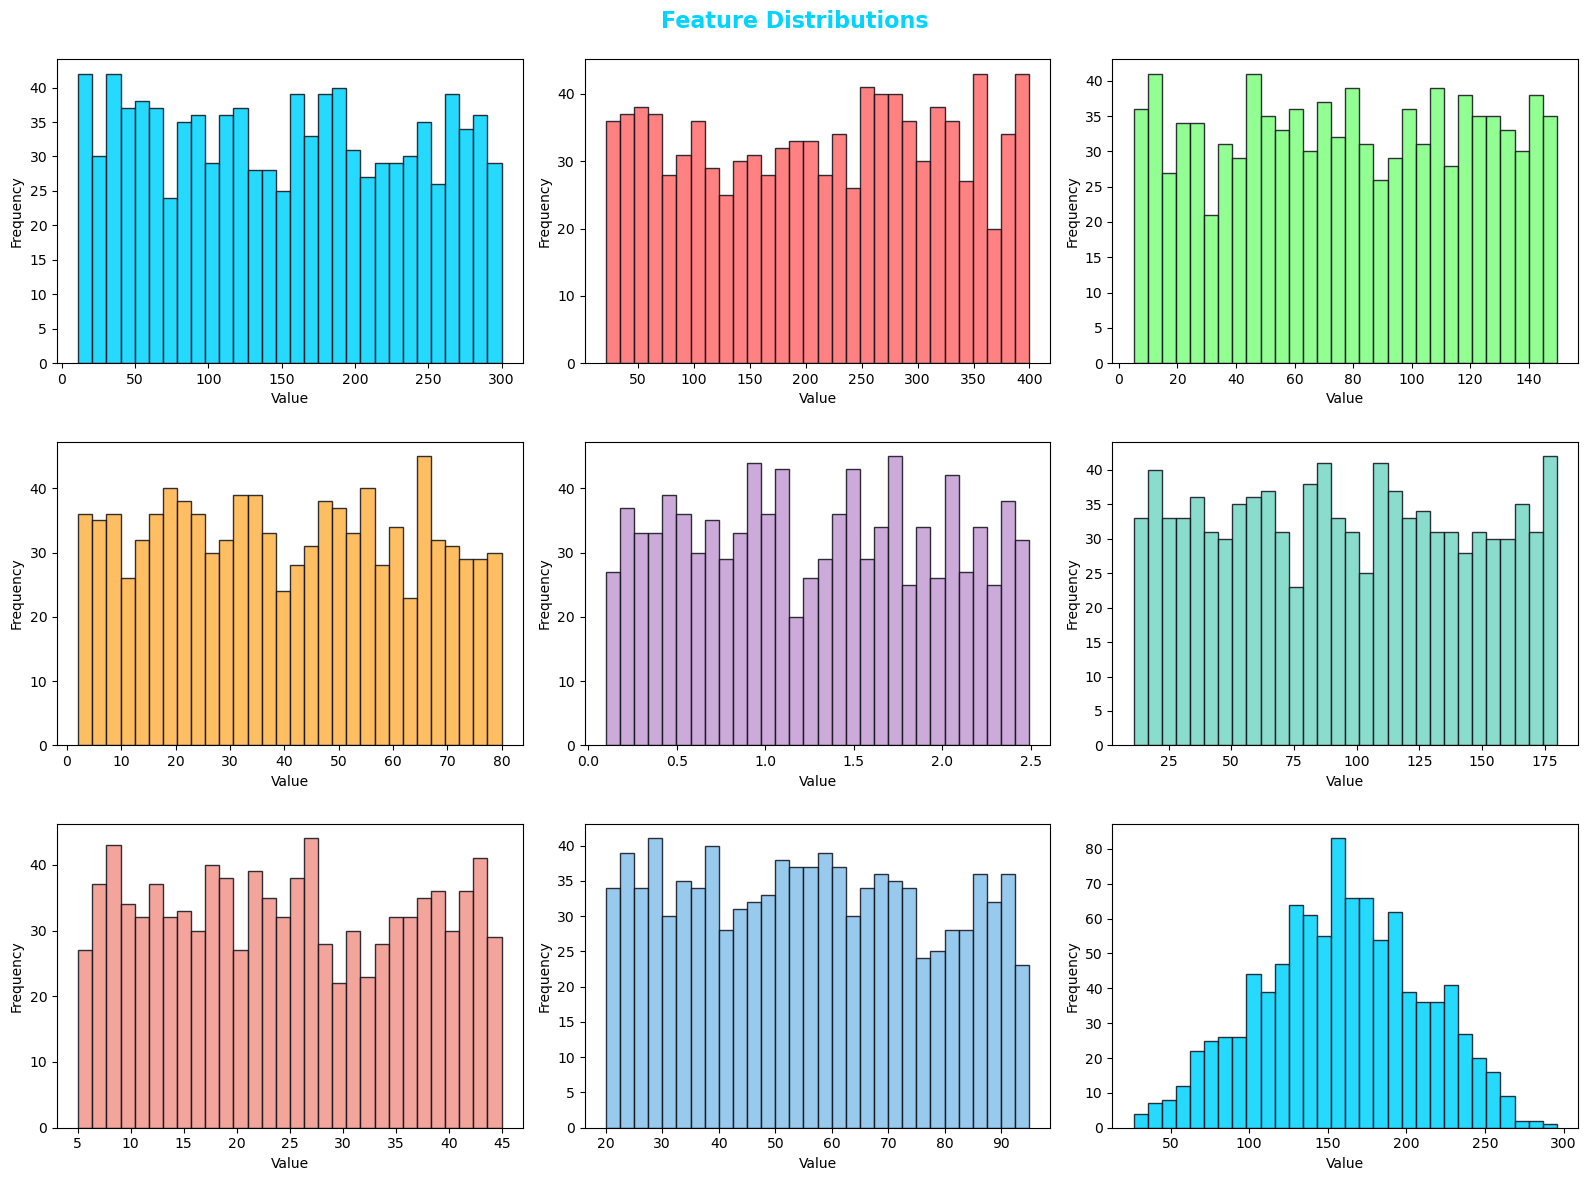

In [21]:
# ── Graph 1: Feature Distributions (Histograms) ──
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold', color='#00d4ff')

for i, (ax, col) in enumerate(zip(axes.flat, features + ['AQI'])):
    ax.hist(df[col], bins=30, color=PALETTE[i % len(PALETTE)],
            edgecolor='#0f0f1a', alpha=0.85)
    ax.set_title(col, fontsize=12, color='white')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

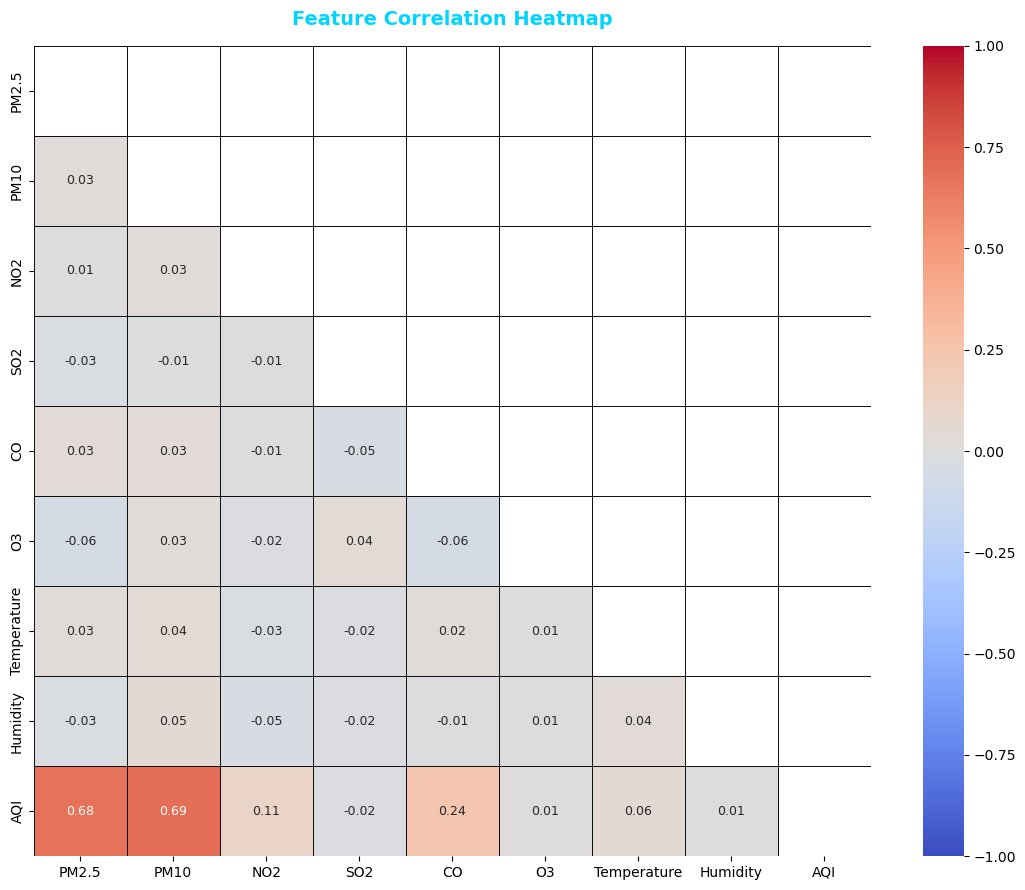

In [22]:
# ── Graph 2: Correlation Heatmap ──
fig, ax = plt.subplots(figsize=(11, 9))
corr = df[features + ['AQI']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, linecolor='#111',
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14,
             fontweight='bold', color='#00d4ff', pad=15)
plt.tight_layout()
plt.show()

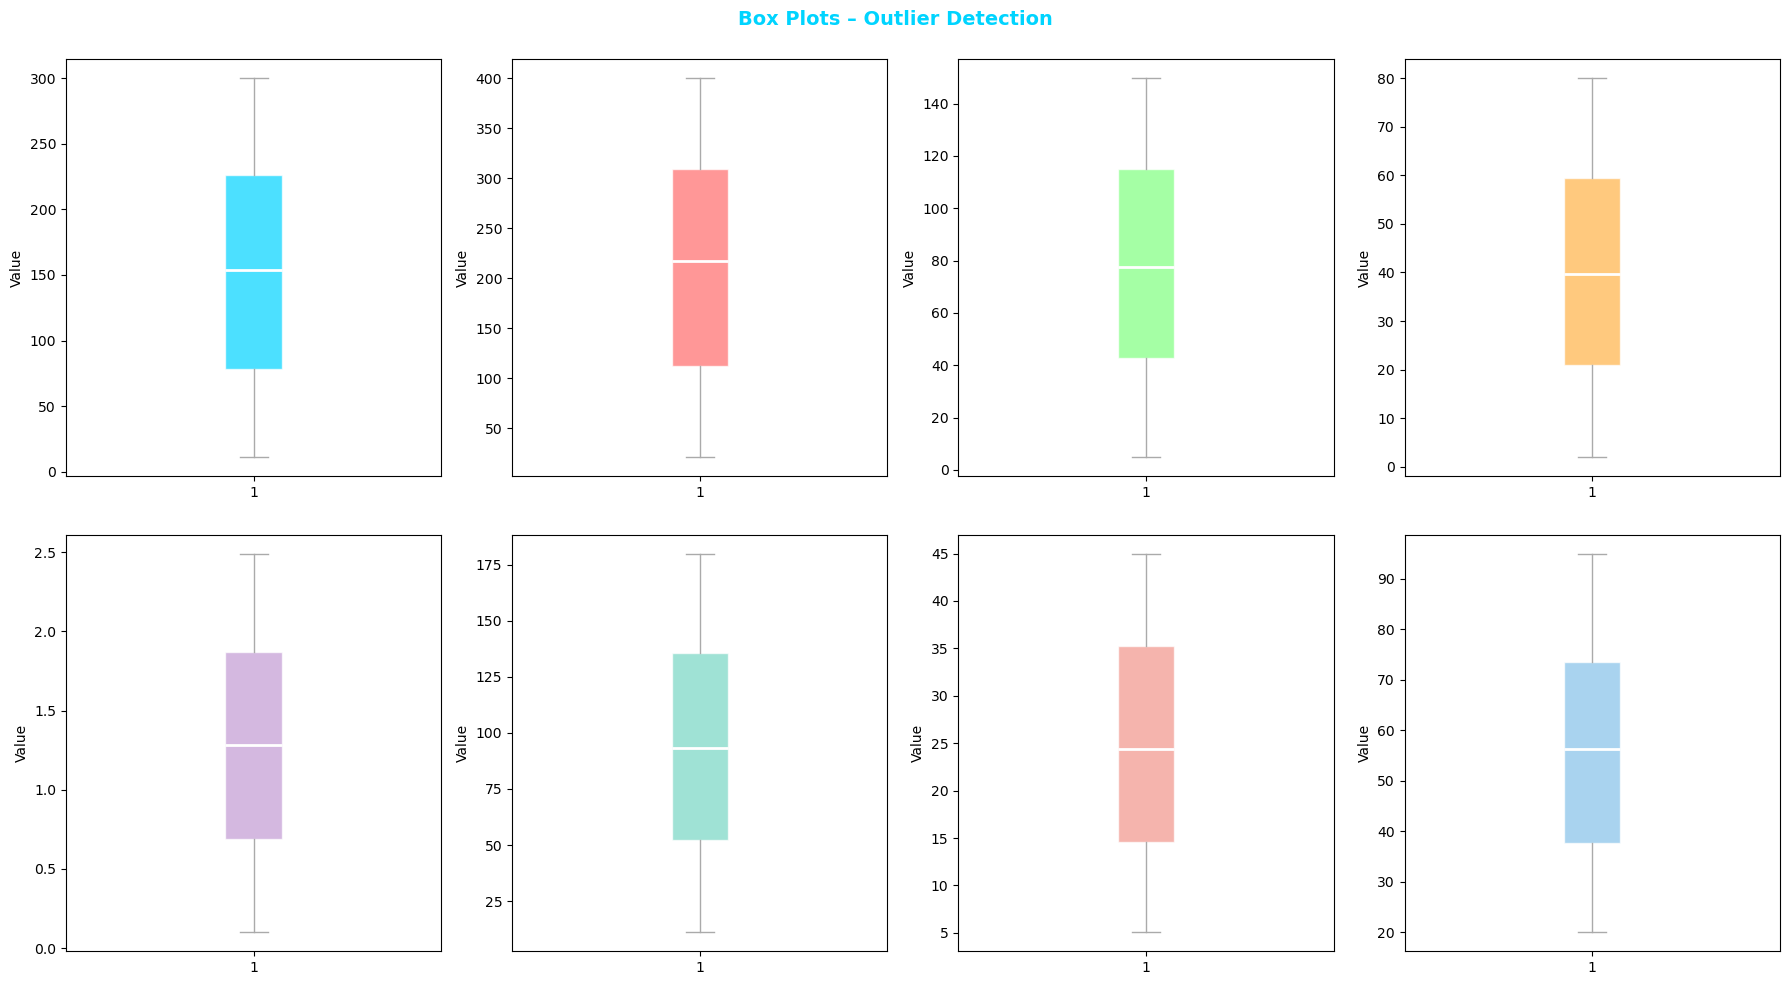

In [23]:
# ── Graph 4: Box Plots — Outlier Visualization ──
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Box Plots – Outlier Detection', fontsize=14,
             fontweight='bold', color='#00d4ff')

for ax, col, color in zip(axes.flat, features, PALETTE):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7, color='white'),
               medianprops=dict(color='white', linewidth=2),
               whiskerprops=dict(color='#aaa'),
               capprops=dict(color='#aaa'),
               flierprops=dict(marker='o', color=color, alpha=0.5, markersize=4))
    ax.set_title(col, color='white')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [25]:
X = df[features].copy()
y = df['AQI'].copy()

In [26]:
# Ratio of fine to coarse particles
X['PM_ratio'] = X['PM2.5'] / (X['PM10'] + 1e-5)

# Combined gas pollutant load
X['NO2_SO2_sum'] = X['NO2'] + X['SO2']

# Weighted Pollution Index
X['Pollution_index'] = (X['PM2.5'] * 0.4 +
                         X['PM10']  * 0.3 +
                         X['NO2']   * 0.2 +
                         X['SO2']   * 0.1)

In [28]:
X.shape

(1000, 11)

In [30]:
X.head(3)

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,PM_ratio,NO2_SO2_sum,Pollution_index
0,118.62,90.35,42.95,54.47,1.47,76.92,30.93,22.91,1.312894,97.42,88.590
1,285.71,225.92,40.81,64.14,2.03,90.48,11.90,34.01,1.264651,104.95,196.636
2,222.28,351.72,136.41,21.54,1.92,155.27,39.90,82.34,0.631980,157.95,223.864


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [33]:
print("Shape of x_train:",X_train.shape)
print("Shape of x_test:",X_test.shape)

Shape of x_train: (800, 11)
Shape of x_test: (200, 11)


In [34]:
print("Shape of y_train:",y_train.shape)
print("Shape of y_test:",y_test.shape)

Shape of y_train: (800,)
Shape of y_test: (200,)


In [35]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# train ml

In [36]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               ExtraTreesRegressor)

In [37]:
# ── Define all 8 models ──
# Format: 'Name': (model_object, needs_scaling)
models = {
    'Linear Regression':(LinearRegression(),True),
    
    'Decision Tree':(DecisionTreeRegressor(max_depth=8,random_state=42),False),
    'Random Forest':(RandomForestRegressor(n_estimators=100,random_state=42),False),
    'Gradient Boosting':(GradientBoostingRegressor(n_estimators=100,random_state=42),False),
    'Extra Trees':(ExtraTreesRegressor(n_estimators=100,random_state=42),False),
    'K-Nearest Neighbors':(KNeighborsRegressor(n_neighbors=5),True),
    
}

print(f"Total models to train: {len(models)}")
for name in models:
    print(f"  • {name}")

Total models to train: 6
  • Linear Regression
  • Decision Tree
  • Random Forest
  • Gradient Boosting
  • Extra Trees
  • K-Nearest Neighbors


In [39]:
# ── Train all models + 5-Fold CV ──
cv      = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"\n{'Model':<30} {'R²':>8} {'RMSE':>8} {'MAE':>8} {'CV R²':>15}")
print("-" * 75)

for name, (model, use_scaled) in models.items():

    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values

    # Train
    model.fit(Xtr, y_train)

    # Predict
    y_pred = model.predict(Xte)

    # Metrics
    mae      = mean_absolute_error(y_test, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    r2       = r2_score(y_test, y_pred)
    cv_sc    = cross_val_score(model, Xtr, y_train, cv=cv, scoring='r2')

    results[name] = {
        'model': model, 'use_scaled': use_scaled, 'y_pred': y_pred,
        'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'CV_mean': cv_sc.mean(), 'CV_std': cv_sc.std()
    }

    print(f"  {name:<28} {r2:>8.4f} {rmse:>8.2f} {mae:>8.2f}   "
          f"{cv_sc.mean():.4f} ± {cv_sc.std():.4f}")




Model                                R²     RMSE      MAE           CV R²
---------------------------------------------------------------------------
  Linear Regression              0.9563    10.99     8.79   0.9580 ± 0.0040
  Decision Tree                  0.8915    17.31    13.69   0.9049 ± 0.0040
  Random Forest                  0.9462    12.19     9.85   0.9440 ± 0.0041
  Gradient Boosting              0.9456    12.26     9.72   0.9491 ± 0.0053
  Extra Trees                    0.9441    12.42     9.96   0.9461 ± 0.0018
  K-Nearest Neighbors            0.8885    17.54    14.19   0.8717 ± 0.0036


In [41]:
# as we can see the best is Linear Regressoin so we will use linear regression for this project

# prediction on new data

In [42]:

def add_engineered_features(X):
    X = X.copy()
    X['PM_ratio']        = X['PM2.5'] / (X['PM10'] + 1e-5)
    X['NO2_SO2_sum']     = X['NO2'] + X['SO2']
    X['Pollution_index'] = (X['PM2.5'] * 0.4 + X['PM10'] * 0.3 +
                             X['NO2']   * 0.2 + X['SO2']  * 0.1)
    return X

In [43]:

new_samples = pd.DataFrame({
    'PM2.5':       [45.0,  180.0, 280.0,  12.0,  95.0],
    'PM10':        [90.0,  240.0, 370.0,  30.0, 155.0],
    'NO2':         [30.0,   90.0, 130.0,  10.0,  55.0],
    'SO2':         [15.0,   50.0,  75.0,   5.0,  30.0],
    'CO':          [ 0.5,    1.5,   2.3,   0.2,   1.0],
    'O3':          [80.0,   60.0,  40.0, 120.0,  90.0],
    'Temperature': [25.0,   32.0,  18.0,  15.0,  28.0],
    'Humidity':    [55.0,   70.0,  45.0,  40.0,  65.0],
})

print("New Input Samples:")
display(new_samples)

New Input Samples:


,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity
0,45.0,90.0,30.0,15.0,0.5,80.0,25.0,55.0
1,180.0,240.0,90.0,50.0,1.5,60.0,32.0,70.0
2,280.0,370.0,130.0,75.0,2.3,40.0,18.0,45.0
3,12.0,30.0,10.0,5.0,0.2,120.0,15.0,40.0
4,95.0,155.0,55.0,30.0,1.0,90.0,28.0,65.0
